In [37]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [39]:
img_size = 224
batch_size = 32

In [40]:
print(os.listdir())
print(os.listdir("dataset"))
print(os.listdir("dataset/train"))

['.dist', 'caseStudy1.ipynb', 'caseStudy2.ipynb', 'caseStudy3.ipynb', 'dataset']
['train']
['no_tumor', 'tumor']


In [41]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [42]:
train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 203 images belonging to 2 classes.


In [43]:
val_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 50 images belonging to 2 classes.


In [44]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(2,activation='softmax'))

In [45]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 610ms/step - accuracy: 0.6305 - loss: 0.8610 - val_accuracy: 0.7000 - val_loss: 0.6562
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 504ms/step - accuracy: 0.6552 - loss: 0.6237 - val_accuracy: 0.7200 - val_loss: 0.6084
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 487ms/step - accuracy: 0.7143 - loss: 0.6303 - val_accuracy: 0.6400 - val_loss: 0.6030
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 587ms/step - accuracy: 0.7537 - loss: 0.5169 - val_accuracy: 0.6400 - val_loss: 0.7217
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 500ms/step - accuracy: 0.7586 - loss: 0.5938 - val_accuracy: 0.7600 - val_loss: 0.5735
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 485ms/step - accuracy: 0.7044 - loss: 0.5955 - val_accuracy: 0.6400 - val_loss: 0.5994
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 497ms/step - accuracy: 0.7438 - loss: 0.5288 - val_accuracy: 0.7400 - val_loss: 0.6180
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 492ms/step - accuracy: 0.7783 - loss: 0.5249 - val_accuracy: 0.6800 - val_loss:

In [48]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.6800 - loss: 0.6683
Validation Accuracy: 0.6800000071525574


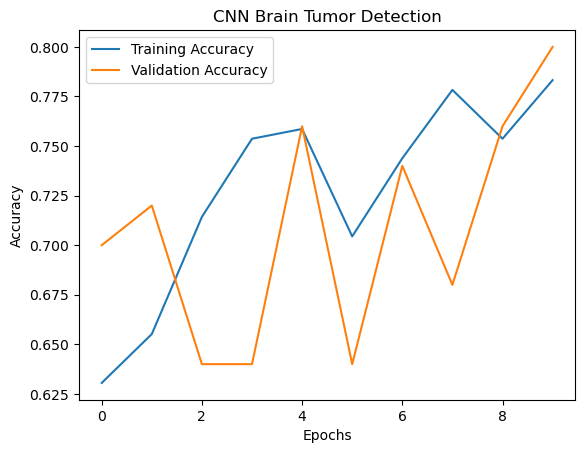

In [49]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Brain Tumor Detection")

plt.show()